In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
folder_path = "/content/drive/MyDrive/archive (5)/data/test"
os.listdir(folder_path)

['Non Accident', 'Accident']

In [ ]:
!nvidia-smi

Tue Mar 18 16:06:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip uninstall tensorflow tensorflow-gpu -y

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0


In [ ]:
import sys
print(sys.version)

3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]


In [ ]:
!pip install tensorflow --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.9 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.19.0 which is incompatible.


In [ ]:
!pip install tensorflow==2.12

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[]


In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.12.0
GPU Available: []


In [ ]:
#re-size all the images to this
IMAGE_SIZE = [224,224]
color_path='/content/drive/MyDrive/archive (5)/data/test'

In [ ]:
#Import the Vgg 16 library as shown below and add preprocessing layer to the front of VGG
#Import the Vgg 16 library as shown below and add preprocessing layer to the front of VGG
#Here we will be using imagenet weights
from tensorflow.keras.applications.inception_v3 import InceptionV3
inception=InceptionV3(input_shape=IMAGE_SIZE +[3],
                      weights='imagenet',include_top=False)

87910968/87910968 [==============================] - 0s 0us/step


In [ ]:
#don't train existing weights
for layer in inception.layers:
  layer.trainable=False

In [ ]:
from glob import glob

folders = glob('/content/drive/MyDrive/archive (5)/data/test/*/')  # Get subfolders inside 'color'

print(f"Number of classes: {len(folders)}")  # Print number of classes (subfolders)
print(folders)  # Print list of class folder

Number of classes: 2
['/content/drive/MyDrive/archive (5)/data/test/Non Accident/', '/content/drive/MyDrive/archive (5)/data/test/Accident/']


In [ ]:
folders

['/content/drive/MyDrive/archive (5)/data/test/Non Accident/',
 '/content/drive/MyDrive/archive (5)/data/test/Accident/']

In [ ]:
from tensorflow.keras.layers import Flatten

x = Flatten()(inception.output)  # Apply Flatten to inception's output


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model

inception = InceptionV3(weights='imagenet', include_top=False)
x = Flatten()(inception.output)

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense  # Import Dense

x = GlobalAveragePooling2D()(inception.output)  # Better than Flatten for CNNs
prediction = Dense(len(folders), activation='softmax')(x)


In [ ]:
# Create the model
model = Model(inputs=inception.input, outputs=prediction)

In [ ]:
#view the structure of the model
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv2d_94 (Conv2D)             (None, None, None,   864         ['input_2[0][0]']                
                                32)                                                               
                                                                                                  
 batch_normalization_94 (BatchN  (None, None, None,   96         ['conv2d_94[0][0]']              
 ormalization)                  32)                                                           

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']  # Corrected spelling
)

In [ ]:
#Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize the ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)

# Use flow_from_directory to load images from the folder
training_set = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/archive (5)/data/test',
    target_size=(224, 224),  # Set the image size
    batch_size=500,           # Set the batch size
    class_mode='categorical' # Use categorical labels for multi-class classification
)

# Print the details of the training set to verify
print(training_set.class_indices)

Found 198 images belonging to 2 classes.
{'Accident': 0, 'Non Accident': 1}


In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!cp /path/to/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d <dataset-name>
!unzip <dataset-name>.zip -d /content/accident_data


cp: cannot stat '/path/to/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `kaggle datasets download -d <dataset-name>'
/bin/bash: line 1: dataset-name: No such file or directory


In [ ]:
!ls "/content/drive/MyDrive/archive (5)/data/test"


 Accident  'Non Accident'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/archive (5)/data/test"))


['Non Accident', 'Accident']


In [ ]:
training_set = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/archive (5)/data/test',
    target_size=(224, 224),
    batch_size=32,  # Reduce batch size
    class_mode='categorical'
)


Found 198 images belonging to 2 classes.


In [ ]:
!pip install google_images_download


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.9/492.9 kB 25.9 MB/s eta 0:00:00
  Created wheel for google_images_download: filename=google_images_download-2.8.0-py2.py3-none-any.whl size=14537 sha256=d79bf34e338b7df965bef341b17123e53b2d1b2c789393a91d44603535a044cd
  Stored in directory: /root/.cache/pip/wheels/dc/83/37/7303b15f3e8a5bfbd5c7ebbfe13f0c666ada6f8efecc6d77ec
Successfully built google_images_download


In [ ]:
!pip install selenium --upgrade  # Upgrade to the latest version
!pip install selenium==<specific_version>  # Install a specific version (e.g., 3.141.0)


/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `pip install selenium==<specific_version>  # Install a specific version (e.g., 3.141.0)'


In [ ]:
!apt-get update
!apt install chromium-chromedriver
!cp /usr/lib/chromium-browser/chromedriver /usr/bin

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [69.9 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,378 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,678 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,692 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,757 kB]
Get:13 https://ppa.laun

In [ ]:
!pip install google_images_search


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.8/865.8 kB 54.9 MB/s eta 0:00:00
  Created wheel for termcolor: filename=termcolor-1.1.0-py3-none-any.whl size=4832 sha256=4d4729dfdc27bef7692bfd12baf1158ce175ba81d7cff810b41b535a4ac2558d
  Stored in directory: /root/.cache/pip/wheels/9f/ca/d7/8f2399d70f5d641d4fef951a78d6aa4ab64cc582e1c4dec9a3
Successfully built termcolor
  Attempting uninstall: termcolor
    Found existing installation: termcolor 2.5.0
    Uninstalling termcolor-2.5.0:
      Successfully uninstalled termcolor-2.5.0
  Attempting uninstall: google-api-python-client
    Found existing installation: google-api-python-client 2.160.0
    Uninstalling google-api-python-client-2.160.0:
      Successfully uninstalled google-api-python-client-2.160.0


In [ ]:
API_KEY = "your_real_google_api_key"
CX = "your_real_search_engine_id"


In [ ]:
!pip install bing-image-downloader


In [ ]:
from bing_image_downloader import downloader

downloader.download("road accident", limit=500, output_dir="dataset", adult_filter_off=True)
downloader.download("safe driving", limit=500, output_dir="dataset", adult_filter_off=True)


Streaming output truncated to the last 5000 lines.
[%] Indexed 8 Images on Page 2468.




[!!]Indexing page: 2469

[%] Indexed 8 Images on Page 2469.




[!!]Indexing page: 2470

[%] Indexed 8 Images on Page 2470.




[!!]Indexing page: 2471

[%] Indexed 8 Images on Page 2471.




[!!]Indexing page: 2472

[%] Indexed 31 Images on Page 2472.




[!!]Indexing page: 2473

[%] Indexed 8 Images on Page 2473.




[!!]Indexing page: 2474

[%] Indexed 8 Images on Page 2474.




[!!]Indexing page: 2475

[%] Indexed 8 Images on Page 2475.




[!!]Indexing page: 2476

[%] Indexed 8 Images on Page 2476.




[!!]Indexing page: 2477

[%] Indexed 8 Images on Page 2477.




[!!]Indexing page: 2478

[%] Indexed 8 Images on Page 2478.




[!!]Indexing page: 2479

[%] Indexed 12 Images on Page 2479.




[!!]Indexing page: 2480

[%] Indexed 8 Images on Page 2480.




[!!]Indexing page: 2481

[%] Indexed 8 Images on Page 2481.




[!!]Indexing page: 2482

[%] Indexed 8 Images on Page 2482.




[!!]Indexing

KeyboardInterrupt: 

In [ ]:
import os
os._exit(0)


In [ ]:
import os

accident_images = len(os.listdir("dataset/road accident")) if os.path.exists("dataset/road accident") else 0
safe_images = len(os.listdir("dataset/safe driving")) if os.path.exists("dataset/safe driving") else 0

print(f"Accident images: {accident_images}")
print(f"Safe driving images: {safe_images}")


Accident images: 500
Safe driving images: 475


In [ ]:
from bing_image_downloader import downloader

# Set a lower limit to avoid unnecessary crawling
downloader.download("road accident", limit=500, output_dir="dataset", adult_filter_off=True, timeout=60)
downloader.download("safe driving", limit=500, output_dir="dataset", adult_filter_off=True, timeout=60)


Streaming output truncated to the last 5000 lines.




[!!]Indexing page: 78

[%] Indexed 35 Images on Page 78.


[%] Downloading Image #131 from http://d2u4q3iydaupsp.cloudfront.net/JLgVRhckk0BsdHWuR0ZwQOEZSvI0qFWoxNsBs6BnpXCgyyzN5ygODrhoWwIZktSGGUOT1HqICUjqK6KioszpEBqqV75bnnHz5RNMLk1MRnlqPQVCZtwvuRDJsmm82iSP
[%] File Downloaded !

[%] Downloading Image #132 from https://di-uploads-pod14.dealerinspire.com/toyotaoforlando/uploads/2020/03/safe-driving.jpg
[%] File Downloaded !



[!!]Indexing page: 79

[%] Indexed 35 Images on Page 79.




[!!]Indexing page: 80

[%] Indexed 35 Images on Page 80.


[%] Downloading Image #133 from https://aws.wideinfo.org/wideinfo.org/wp-content/uploads/2018/04/27225523/safedriving.jpg
[%] File Downloaded !



[!!]Indexing page: 81

[%] Indexed 35 Images on Page 81.


[%] Downloading Image #134 from https://ourautocity.com/wp-content/uploads/2023/08/What-Are-the-Best-Tips-for-Driving-Safely-1.jpg
[%] File Downloaded !

[%] Downloading Image #135 from http

KeyboardInterrupt: 

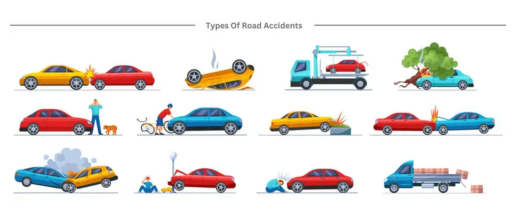

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2

# Load and display a random image from the accident dataset
accident_folder = "dataset/road accident"
if os.path.exists(accident_folder):
    random_img = os.path.join(accident_folder, os.listdir(accident_folder)[0])
    img = cv2.imread(random_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("No images found in accident folder!")


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os


In [ ]:
# Define dataset paths
train_dir = "dataset"  # Change if your dataset is in another folder

# Data augmentation for training images
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% of data for validation
)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',  # Use 'categorical' if more than two classes
    subset='training'
)

# Load validation data
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 992 images belonging to 2 classes.
Found 248 images belonging to 2 classes.


In [ ]:
# Build a simple CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Use `softmax` for multi-class classification
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# First, let's check your dataset structure
import os

# Print the contents of your dataset directory
print("Dataset directory structure:")
print(os.listdir("dataset"))

# Make sure you have the correct subdirectories for classes
road_accident_path = "dataset/road accident"
safe_driving_path = "dataset/safe driving"

if os.path.exists(road_accident_path):
    print(f"Found 'road accident' directory with {len(os.listdir(road_accident_path))} images")
else:
    print("'road accident' directory not found")

if os.path.exists(safe_driving_path):
    print(f"Found 'safe driving' directory with {len(os.listdir(safe_driving_path))} images")
else:
    print("'safe driving' directory not found")

Dataset directory structure:
['road accident', 'safe driving']
Found 'road accident' directory with 645 images
Found 'safe driving' directory with 639 images


Found 995 images belonging to 2 classes.
Found 245 images belonging to 2 classes.
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Initial training with frozen base model...
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.5180 - loss: 0.9427

63/63 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.5184 - loss: 0.9414 - val_accuracy: 0.4939 - val_loss: 1.0859 - learning_rate: 0.0010
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.5377 - loss: 0.8437

63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 644ms/step - accuracy: 0.5377 - loss: 0.8435 - val_accuracy: 0.5102 - val_loss: 0.8548 - learning_rate: 0.0010
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.5032 - loss: 0.9247

63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 583ms/step - accuracy: 0.5033 - loss: 0.9240 - val_accuracy: 0.5143 - val_loss: 0.7461 - learning_rate: 0.0010
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.5324 - loss: 0.8097

63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 632ms/step - accuracy: 0.5322 - loss: 0.8097 - val_accuracy: 0.5224 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 552ms/step - accuracy: 0.5599 - loss: 0.7840 - val_accuracy: 0.5184 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 637ms/step - accuracy: 0.5078 - loss: 0.7862 - val_accuracy: 0.4939 - val_loss: 0.8096 - learning_rate: 0.0010
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.4848 - loss: 0.8081

63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 571ms/step - accuracy: 0.4850 - loss: 0.8079 - val_accuracy: 0.6571 - val_loss: 0.6697 - learning_rate: 0.0010
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 578ms/step - accuracy: 0.5355 - loss: 0.7565 - val_accuracy: 0.6163 - val_loss: 0.6594 - learning_rate: 0.0010
Epoch 9/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 549ms/step - accuracy: 0.5268 - loss: 0.7489 - val_accuracy: 0.4939 - val_loss: 0.6956 - learning_rate: 0.0010
Epoch 10/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 566ms/step - accuracy: 0.5182 - loss: 0.7377 - val_accuracy: 0.5061 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 11/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 592ms/step - accuracy: 0.5310 - loss: 0.7453 - val_accuracy: 0.6000 - val_loss: 0.6736 - learning_rate: 0.0010
Epoch 12/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 617ms/step - accuracy: 0.5552 - loss: 0.7162 - val_accuracy: 0.5143 - val_loss: 0.7947 - learning_rate: 0.0010
Epoch 13/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 614ms/step - accuracy: 0.5265 - loss: 0.7343 - 

63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 588ms/step - accuracy: 0.5487 - loss: 0.7770 - val_accuracy: 0.6694 - val_loss: 0.6254 - learning_rate: 5.0000e-05
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 622ms/step - accuracy: 0.5634 - loss: 0.7342 - val_accuracy: 0.6490 - val_loss: 0.6520 - learning_rate: 5.0000e-05
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 620ms/step - accuracy: 0.5433 - loss: 0.7532 - val_accuracy: 0.6327 - val_loss: 0.6497 - learning_rate: 5.0000e-05
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 568ms/step - accuracy: 0.5342 - loss: 0.7621 - val_accuracy: 0.6449 - val_loss: 0.6437 - learning_rate: 5.0000e-05
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 622ms/step - accuracy: 0.5398 - loss: 0.7390 - val_accuracy: 0.6449 - val_loss: 0.6394 - learning_rate: 5.0000e-05
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 572ms/step - accuracy: 0.5525 - loss: 0.7249 - val_accuracy: 0.6082 - val_loss: 0.6512 - learning_rate: 5.0000e-05
Epoch 16/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 617ms/step - accuracy

63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 578ms/step - accuracy: 0.5637 - loss: 0.7555 - val_accuracy: 0.7020 - val_loss: 0.6016 - learning_rate: 2.0000e-06
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 568ms/step - accuracy: 0.5572 - loss: 0.7508 - val_accuracy: 0.6571 - val_loss: 0.6201 - learning_rate: 2.0000e-06


16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 743ms/step - accuracy: 0.6798 - loss: 0.5744
Final validation accuracy: 60.00%


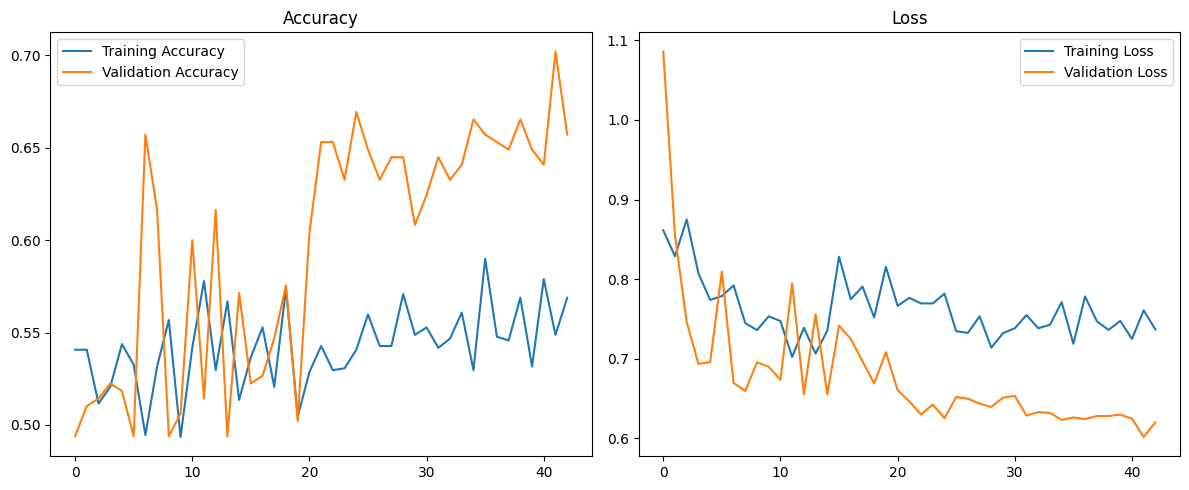

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

# 1. Create data generators with more aggressive augmentation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=False,  # Keep this false for road scenes
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],  # Add brightness variation
    validation_split=0.2  # Use 20% for validation
)

# 2. Set up data generators
batch_size = 16  # Smaller batch size for better generalization

train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    'dataset/validation',
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# 3. Create a model with EfficientNetB3 as base (better performance/size ratio)
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 4. Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 5. Freeze base model for initial training
for layer in base_model.layers:
    layer.trainable = False

# 6. Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 7. Set up callbacks
callbacks = [
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-6, monitor='val_loss')
]

# 8. Initial training with frozen base
print("Initial training with frozen base model...")
history1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

# 9. Unfreeze some layers for fine-tuning
print("Fine-tuning model...")
# Unfreeze the top layers of the base model
for layer in base_model.layers[-30:]:  # Unfreeze the last 30 layers
    layer.trainable = True

# 10. Recompile with a much lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00005),  # Very low learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 11. Continue training with unfrozen layers
history2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# 12. Use class weights if needed (if classes are imbalanced)
class_weights = {
    0: 1.0,  # Adjust these values if your classes are imbalanced
    1: 1.0
}

# 13. Final round of fine-tuning with class weights
print("Final fine-tuning...")
history3 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Load the best model
model = tf.keras.models.load_model('best_model.h5')

# Evaluate final performance
final_loss, final_accuracy = model.evaluate(validation_generator)
print(f"Final validation accuracy: {final_accuracy*100:.2f}%")

# Plot accuracy and loss
def plot_training_history(history_list):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for history in history_list:
        if history is not None:
            for key in history.history:
                if key == 'accuracy':
                    acc.extend(history.history['accuracy'])
                elif key == 'val_accuracy':
                    val_acc.extend(history.history['val_accuracy'])
                elif key == 'loss':
                    loss.extend(history.history['loss'])
                elif key == 'val_loss':
                    val_loss.extend(history.history['val_loss'])

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Loss')

    plt.tight_layout()
    plt.show()

plot_training_history([history1, history2, history3])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

training_set = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/archive (5)/data/train',  # Ensure correct directory
    target_size=(224, 224),
    batch_size=16,  # Reduce batch size if needed
    class_mode='categorical'
)


Found 838 images belonging to 2 classes.


In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define paths to dataset (Make sure 'train' and 'test' directories exist)
train_dir = "/content/drive/MyDrive/archive (5)/data/train"
test_dir = "/content/drive/MyDrive/archive (5)/data/test"

# Data Augmentation for Training Set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only Rescaling for Test Set
test_datagen = ImageDataGenerator(rescale=1./255)

# Load Training Data
training_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,  # Adjust based on GPU memory
    class_mode='categorical'
)

# Load Testing Data
test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False  # No need to shuffle test data
)

# CNN Model Architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Prevent Overfitting
    Dense(training_set.num_classes, activation='softmax')  # Output Layer
])

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    training_set,
    validation_data=test_set,
    epochs=20,  # Adjust based on performance
    steps_per_epoch=len(training_set),
    validation_steps=len(test_set)
)

# Save Model
model.save("/content/drive/MyDrive/plant_disease_cnn_model.h5")

# Evaluate Model on Test Data
loss, accuracy = model.evaluate(test_set)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Found 838 images belonging to 2 classes.
Found 198 images belonging to 2 classes.
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5299 - loss: 0.7219 - val_accuracy: 0.4697 - val_loss: 0.6943
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 692ms/step - accuracy: 0.5223 - loss: 0.6934 - val_accuracy: 0.4747 - val_loss: 0.6945
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 703ms/step - accuracy: 0.4935 - loss: 0.6975 - val_accuracy: 0.5657 - val_loss: 0.6899
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 665ms/step - accuracy: 0.5521 - loss: 0.6918 - val_accuracy: 0.5707 - val_loss: 0.6873
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 799ms/step - accuracy: 0.5782 - loss: 0.6872 - val_accuracy: 0.5859 - val_loss: 0.6838
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 661ms/step - accuracy: 0.5518 - loss: 0.6892 - val_accuracy: 0.5758 - val_loss: 0.6801
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 687ms/step - accuracy: 0.5498 - loss: 0.6904 - val_accuracy: 0.5707 - val_loss: 0.6773
Epoch 8/20
53/53 

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.5716 - loss: 0.6443
Test Accuracy: 62.63%


In [ ]:
!ls /content/drive/MyDrive/


'71812305001(A.Abinaya).pdf'  'Colab Notebooks'       'OOPS ALM.pdf'
'A.Abinaya(71812305001).pdf'   color		       plant_disease_cnn_model.h5
'archive (5)'		      'Java certificate.pdf'


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Car.jpg to Car.jpg


In [ ]:
!mv Car.jpg /content/drive/MyDrive/


In [ ]:
predicted_label, confidence = predict_image(img_path)
print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Images/Car.jpg'

In [ ]:
from google.colab import files

uploaded = files.upload()  # This will prompt you to upload the image manually


Saving Car.jpg to Car.jpg


In [ ]:
!ls -lh Car.jpg


-rw-r--r-- 1 root root 228K Mar 19 14:32 Car.jpg


In [ ]:
img_path = "Car.jpg"  # No Google Drive needed


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Import ImageDataGenerator

def predict_image(img_path, training_set):  # Add training_set as argument
    """
    Predicts the class of an image using the trained CNN model.

    Args:
        img_path (str): Path to the image to predict.
        training_set (ImageDataGenerator): The training set used for the model.

    Returns:
        tuple: (predicted_label, confidence) where predicted_label is the
               name of the predicted class and confidence is the prediction
               probability.
    """

    # Load the saved model
    model = tf.keras.models.load_model("/content/drive/MyDrive/plant_disease_cnn_model.h5")

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = img / 255.0  # Rescale pixel values

    # Make the prediction
    prediction = model.predict(img)

    # Get predicted class and confidence
    predicted_class_index = np.argmax(prediction)
    class_labels = list(training_set.class_indices.keys())  # Get labels from training set
    predicted_label = class_labels[predicted_class_index]
    confidence = prediction[0][predicted_class_index] * 100

    return predicted_label, confidence

# Before calling predict_image, create or load your training_set:
# Assuming you have already defined your `train_datagen`
training_set = train_datagen.flow_from_directory('/content/drive/MyDrive/archive (5)/data/train',  # Ensure correct directory
    target_size=(224, 224),
    batch_size=16,  # Reduce batch size if needed
    class_mode='categorical'
)

# Now you can call the function, passing the training_set
img_path = "Car.jpg"  # No Google Drive needed
predicted_label, confidence = predict_image(img_path, training_set)  # Pass training_set
print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")

NameError: name 'train_datagen' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    """
    Predict the class of an image using the trained CNN model.
    """
    # Load the trained model
    model = tf.keras.models.load_model("/content/drive/MyDrive/plant_disease_cnn_model.h5")

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))  # Resize to match model input
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize

    # Predict the class
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]  # Get class index
    confidence = np.max(predictions) * 100  # Get confidence score

    return predicted_class, confidence

# Test the uploaded image
img_path = "Car.jpg"  # No need for Google Drive, using local file
predicted_label, confidence = predict_image(img_path)

print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Predicted Class: 1, Confidence: 62.43%


In [ ]:
import os

train_dir = "/content/drive/MyDrive/archive (5)/data/train"

# Get class labels from the folder names
class_labels = sorted(os.listdir(train_dir))
print(class_labels)



['Accident', 'Non Accident']


In [ ]:
img_path = "Car.jpg"  # Replace with your new image
predicted_label, confidence = predict_image(img_path)
print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Predicted Class: 1, Confidence: 62.43%


In [ ]:
import os

file_path = "C:\Users\harir\OneDrive\Desktop\Bike.jpg"
print("File exists:", os.path.exists(file_path))


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (<ipython-input-8-dfd17f1a5770>, line 3)

In [ ]:
from google.colab import files
uploaded = files.upload()  # Select 'Bike.jpg' when prompted



Saving Bike.jpg to Bike.jpg


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
img_path = "/content/drive/My Drive/Bike.jpg"


In [ ]:
img_path = "/content/Bike.jpg"


In [ ]:
predicted_label, confidence = predict_image(img_path)
print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
Predicted Class: Non Accident, Confidence: 67.04%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/plant_disease_cnn_model.h5")

# Define function to make predictions
def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch
    img_array = img_array / 255.0  # Normalize

    # Ensure model is compiled before prediction
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Make prediction
    predictions = model.predict(img_array)  # Output is a NumPy array
    class_idx = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    # Use correct class labels (replace with actual labels from training set)
    class_labels = ['Accident', 'Non Accident']
    predicted_label = class_labels[class_idx]

    return predicted_label, confidence

# Test an image
img_path = "Car.jpg"  # Ensure this file exists
predicted_label, confidence = predict_image(img_path)

print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted Class: Non Accident, Confidence: 62.43%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/plant_disease_cnn_model.h5")

# Define function to make predictions
def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch
    img_array = img_array / 255.0  # Normalize

    # Ensure model is compiled before prediction
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Make prediction
    predictions = model.predict(img_array)  # Output is a NumPy array
    class_idx = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    # Use correct class labels (replace with actual labels from training set)
    class_labels = ['Accident', 'Non Accident']
    predicted_label = class_labels[class_idx]

    return predicted_label, confidence

# Test an image
img_path = "Bike.jpg"  # Ensure this file exists
predicted_label, confidence = predict_image(img_path)

print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")


FileNotFoundError: [Errno 2] No such file or directory: 'Bike.jpg'

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\harir\\OneDrive\\Desktop\\Bike.jpg'

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/plant_disease_cnn_model.h5")

# Define function to make predictions
def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch
    img_array = img_array / 255.0  # Normalize

    # Ensure model is compiled before prediction
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Make prediction
    predictions = model.predict(img_array)  # Output is a NumPy array
    class_idx = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    # Use correct class labels (replace with actual labels from training set)
    class_labels = ['Accident', 'Non Accident']
    predicted_label = class_labels[class_idx]

    # Display the image with predicted label
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.show()

    return predicted_label, confidence

# Test an image
img_path = "Car.jpg"  # Ensure this file exists
predicted_label, confidence = predict_image(img_path)


FileNotFoundError: [Errno 2] No such file or directory: 'Car.jpg'

In [ ]:
!ls -lh


total 252K
-rw-r--r-- 1 root root 241K Mar 19 15:29 Bike.jpg
drwx------ 6 root root 4.0K Mar 19 15:20 drive
drwxr-xr-x 1 root root 4.0K Mar 17 13:32 sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Car.jpg to Car.jpg


In [ ]:
img_path = "Car.jpg"  # Ensure it matches the uploaded filename


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
img_path = "/content/drive/MyDrive/Car.jpg"


Saving Car.jpg to Car (1).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


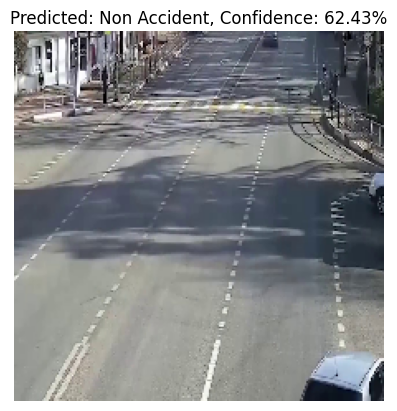

Predicted Class: Non Accident, Confidence: 62.43%


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

# Upload image manually
uploaded = files.upload()

# Get the uploaded file name
img_path = list(uploaded.keys())[0]  # This will take the uploaded image's name dynamically

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/plant_disease_cnn_model.h5")

# Define function to make predictions
def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for batch
    img_array = img_array / 255.0  # Normalize

    # Ensure model is compiled before prediction
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Make prediction
    predictions = model.predict(img_array)  # Output is a NumPy array
    class_idx = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    # Use correct class labels (replace with actual labels from training set)
    class_labels = ['Accident', 'Non Accident']
    predicted_label = class_labels[class_idx]

    return predicted_label, confidence, img  # Return the image for display

# Make Prediction
predicted_label, confidence, img = predict_image(img_path)

# Display the Image with Prediction
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_label}, Confidence: {confidence:.2f}%")
plt.show()

# Print the result
print(f"Predicted Class: {predicted_label}, Confidence: {confidence:.2f}%")
